# Gráficas de sensibilidad: influencia de T y E
Requiere `resultados_agregados_random.csv` y `resultados_detalle_random.csv` en el mismo directorio.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('resultados_agregados_random.csv')
df_det = pd.read_csv('resultados_detalle_random.csv')

In [2]:
df

,T,E,logloss_perdido_medio,logloss_perdido_std,iter_ahorradas_media,iter_ahorradas_std,n_datasets
0,5,-0.2,2.9938,4.9388,88.4390,6.6495,20
1,5,-0.1,1.7561,3.0266,85.2123,9.3112,20
2,5,0.0,1.5250,3.0807,75.9947,13.2591,20
3,5,0.1,0.9122,2.8962,42.6179,32.0236,20
4,10,-0.2,3.8480,5.3850,88.4473,7.0001,20
5,10,-0.1,2.1392,3.0423,86.8820,7.7438,20
6,10,0.0,1.7359,2.7180,79.9335,11.8408,20
7,10,0.1,0.4344,1.0253,46.1936,34.7812,20
8,15,-0.2,3.9703,6.9985,85.1786,8.1417,20
9,15,-0.1,3.2049,6.1687,82.1630,9.7104,20


In [3]:
df_det

,T,E,fold_cv,task_id,logloss_poda,logloss_real,logloss_perdido(%),n_iter_poda,n_iter_real,iter_ahorradas(%),sesgo_calibracion
0,5,-0.2,0,146820,0.038271,0.038271,0.0000,219513,1740856,87.3905,-0.094737
1,5,-0.2,0,168350,0.235516,0.233520,0.8547,213757,1704624,87.4602,-0.044119
2,5,-0.2,0,190392,0.374188,0.331513,12.8728,125401,2030996,93.8256,0.077823
3,5,-0.2,0,359956,0.295673,0.292846,0.9654,131063,1344127,90.2492,-0.018038
4,5,-0.2,0,359965,0.015906,0.015906,0.0000,343984,2178742,84.2118,-0.101787
...,...,...,...,...,...,...,...,...,...,...,...
315,20,0.1,2,190410,0.441339,0.433740,1.7520,1607310,2133582,24.6661,0.055669
316,20,0.1,2,190411,0.293145,0.293145,0.0000,904418,1588070,43.0492,0.001757
317,20,0.1,2,359962,0.311685,0.311685,0.0000,640241,821816,22.0944,0.022696
318,20,0.1,2,359968,0.141681,0.141681,0.0000,641522,1567975,59.0860,-0.049975


### Configuración de estilo global

In [4]:
COLOR_E = {
    -0.2: '#A32D2D',
    -0.1: '#F08080',   
     0.0: '#1D9E75',
     0.1: '#085041',
}

MARKER_T = {
     5: 'o',
    10: 's',
    15: '^',
    20: 'D',
}

LABEL_E = {
    -0.2: 'E = −0.2   (agresiva)',
    -0.1: 'E = −0.1',
     0.0: 'E = 0',
     0.1: 'E = 0.1     (conservadora)',
}

T_vals = [5, 10, 15, 20]
E_vals = [-0.2, -0.1, 0.0, 0.1]

## Gráfica 1: Compromiso ahorro-degradación

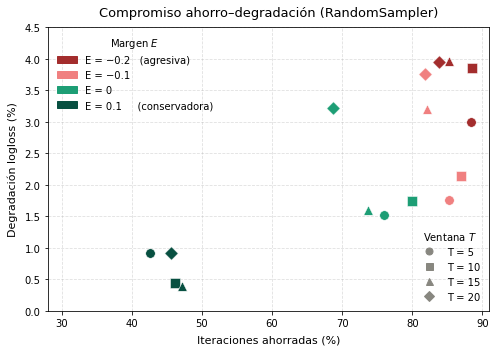

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

for _, row in df.iterrows():
    T = int(row['T'])
    E = round(float(row['E']), 1)
    ax.scatter(
        row['iter_ahorradas_media'],
        row['logloss_perdido_medio'],
        color=COLOR_E[E],
        marker=MARKER_T[T],
        s=90,
        zorder=3,
        linewidths=0.5,
        edgecolors='white',
    )

# Leyenda de colores (E)
legend_E = [
    mpatches.Patch(color=COLOR_E[e], label=LABEL_E[e])
    for e in E_vals
]

# Leyenda de marcadores (T)
legend_T = [
    plt.Line2D([0], [0], marker=MARKER_T[t], color='#888780',
               linestyle='None', markersize=7, label=f'T = {t}')
    for t in T_vals
]

leg1 = ax.legend(handles=legend_E, title='Margen $E$', loc='upper left',
                 frameon=False, title_fontsize=10)
ax.add_artist(leg1)
ax.legend(handles=legend_T, title='Ventana $T$', loc='lower right',
          frameon=False, title_fontsize=10)

ax.set_xlabel('Iteraciones ahorradas (%)', fontsize=11, labelpad=7)
ax.set_ylabel('Degradación logloss (%)', fontsize=11, labelpad=7)
ax.set_title('Compromiso ahorro–degradación (RandomSampler)', fontsize=13, pad=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(28, 91)
ax.set_ylim(0, 4.5)

plt.tight_layout()
#plt.savefig('scatter_TPE.png', bbox_inches='tight', facecolor='white', dpi=230)
plt.show()

## Gráfica 2: Efecto de E fijando T 

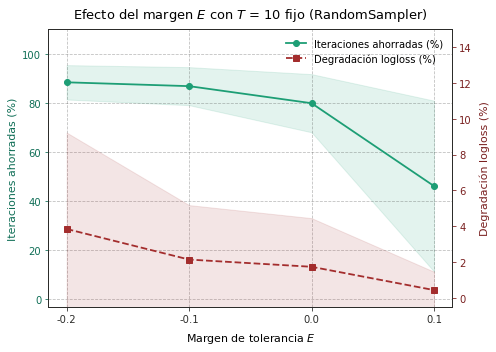

In [6]:
T_FIJO = 10
sub = df[df['T'] == T_FIJO].sort_values('E')

fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#2C2C2A')
        spine.set_linewidth(1.0)

x = sub['E'].values

ax1.plot(x, sub['iter_ahorradas_media'], color='#1D9E75', marker='o',
         linewidth=1.8, markersize=6, label='Iteraciones ahorradas (%)')
ax1.fill_between(
    x,
    sub['iter_ahorradas_media'] - sub['iter_ahorradas_std'],
    sub['iter_ahorradas_media'] + sub['iter_ahorradas_std'],
    color='#1D9E75', alpha=0.12
)

ax2.plot(x, sub['logloss_perdido_medio'], color='#A32D2D', marker='s',
         linewidth=1.8, markersize=6, linestyle='--', label='Degradación logloss (%)')
ax2.fill_between(
    x,
    sub['logloss_perdido_medio'] - sub['logloss_perdido_std'],
    sub['logloss_perdido_medio'] + sub['logloss_perdido_std'],
    color='#A32D2D', alpha=0.12
)

ax1.set_xlabel('Margen de tolerancia $E$', labelpad=7, fontsize=11)
ax1.set_ylabel('Iteraciones ahorradas (%)', color='#0F6E56', labelpad=5, fontsize=11)
ax2.set_ylabel('Degradación logloss (%)', color='#791F1F', labelpad=7, fontsize=11)

ax1.tick_params(axis='y', colors='#0F6E56')
ax2.tick_params(axis='y', colors='#791F1F')
ax1.tick_params(axis='x', colors='#2C2C2A')

ax1.set_xticks(E_vals)
ax1.set_xticklabels([str(e) for e in E_vals], fontsize=10)

ax1.set_title(f'Efecto del margen $E$ con $T$ = {T_FIJO} fijo (RandomSampler)',
              pad=11, fontsize=13)

ax1.grid(True, linestyle='--', alpha=0.3, color='#2C2C2A')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=10)

ax1.set_ylim(-3, 110)
ax2.set_ylim(-0.5, 15)

plt.tight_layout()
#plt.savefig(f'efectoE_TPE.png', bbox_inches='tight', facecolor='white', dpi=230)
plt.show()